# Clair DAG Exploration

This notebook demonstrates how to load, query, and visualize a Clair project's
dependency graph using the `get_dag()` API. We use the `example_1` project
included in this repository.

Data flows **top → bottom**: sources at the top, downstream models at the bottom.

In [1]:
import subprocess
from pathlib import Path
from clair.lineage import get_dag

GIT_ROOT = Path(subprocess.check_output(["git", "rev-parse", "--show-toplevel"]).decode().strip())
PROJECT = GIT_ROOT / "example_projects" / "example_1"

dag = get_dag(PROJECT)
print(f"Nodes: {dag.number_of_nodes()}, Edges: {dag.number_of_edges()}")

Nodes: 3, Edges: 2


## Inspect Nodes and Metadata

Each node carries the full Trouve metadata — type, dependencies, and SQL.

In [2]:
for name in sorted(dag.nodes):
    trouve = dag.get_trouve(name)
    deps = list(dag.predecessors(name))
    print(f"{name}  [{trouve.type.value.upper()}]  deps={deps}")

demo.analytics.daily_event_counts  [TABLE]  deps=['demo.raw.events']
demo.analytics.top_event_types  [TABLE]  deps=['demo.analytics.daily_event_counts']
demo.raw.events  [SOURCE]  deps=[]


## Static Visualization (top → bottom)

Sources are gray, tables are blue, views are green.
Nodes are arranged by depth so data flows from top to bottom.

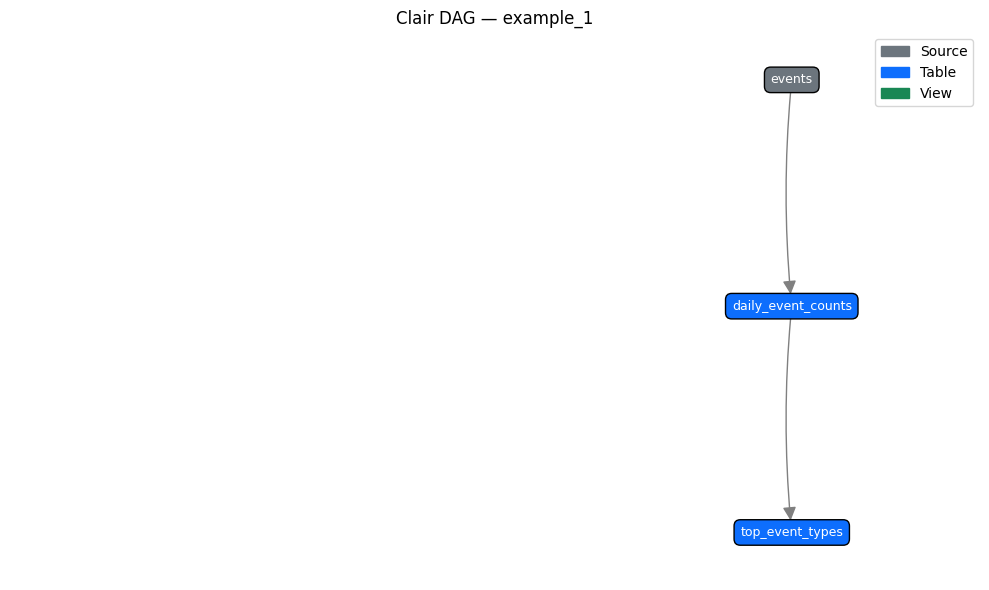

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from collections import defaultdict
from clair.core.dag import ClairDag

color_map = {"source": "#6c757d", "table": "#0d6efd", "view": "#198754"}


def dag_layout(g: ClairDag):
    """Hierarchical top-to-bottom layout: depth 0 at top, deeper nodes lower."""
    depth = {}
    for node in nx.topological_sort(g):
        preds = list(g.predecessors(node))
        depth[node] = 0 if not preds else max(depth[p] for p in preds) + 1
    by_depth = defaultdict(list)
    for node, d in depth.items():
        by_depth[d].append(node)
    pos = {}
    for d, nodes in by_depth.items():
        nodes = sorted(nodes)
        n = len(nodes)
        for i, node in enumerate(nodes):
            pos[node] = (i - (n - 1) / 2, -d)
    return pos


pos = dag_layout(dag)
colors = [color_map[dag.get_trouve(n).type.value] for n in dag.nodes]

fig, ax = plt.subplots(figsize=(10, 6))

nx.draw_networkx_edges(
    dag, pos, ax=ax, arrows=True, arrowsize=20,
    edge_color="gray", connectionstyle="arc3,rad=0.05",
)

for node, (x, y) in pos.items():
    label = node.split(".")[-1]
    color = color_map[dag.get_trouve(node).type.value]
    ax.text(
        x, y, label,
        ha="center", va="center",
        fontsize=9, color="white",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor=color,
            edgecolor="black",
            linewidth=1,
        ),
        zorder=3,
    )

legend_handles = [
    mpatches.Patch(color=c, label=t.capitalize()) for t, c in color_map.items()
]
ax.legend(handles=legend_handles, loc="upper right")
ax.set_title("Clair DAG — example_1")
ax.axis("off")
plt.tight_layout()
plt.show()


## Interactive Visualization (top → bottom)

Uses pyvis with a hierarchical `UD` layout so data flows top → bottom.
Hover a node to see its full name; drag to rearrange.

In [4]:
from pyvis.network import Network
from IPython.display import IFrame

net = Network(directed=True, height="420px", width="100%", cdn_resources="remote")
net.set_options("""
{
  "layout": {
    "hierarchical": {
      "enabled": true,
      "direction": "UD",
      "sortMethod": "directed",
      "levelSeparation": 100,
      "nodeSpacing": 160
    }
  },
  "physics": { "enabled": false },
  "edges": { "arrows": { "to": { "enabled": true } } }
}
""")

for name in dag.nodes:
    trouve = dag.get_trouve(name)
    net.add_node(
        name,
        label=name.split(".")[-1],
        title=name,
        color=color_map[trouve.type.value],
    )
for src, tgt in dag.edges:
    net.add_edge(src, tgt)

net.write_html("dag.html")
IFrame("dag.html", width="100%", height="440px")

## Subgraph Filtering

Filter the DAG to a node and its upstream ancestors — the notebook
equivalent of `clair dag --select`.

Upstream of demo.analytics.daily_event_counts:
  2 nodes, 1 edges


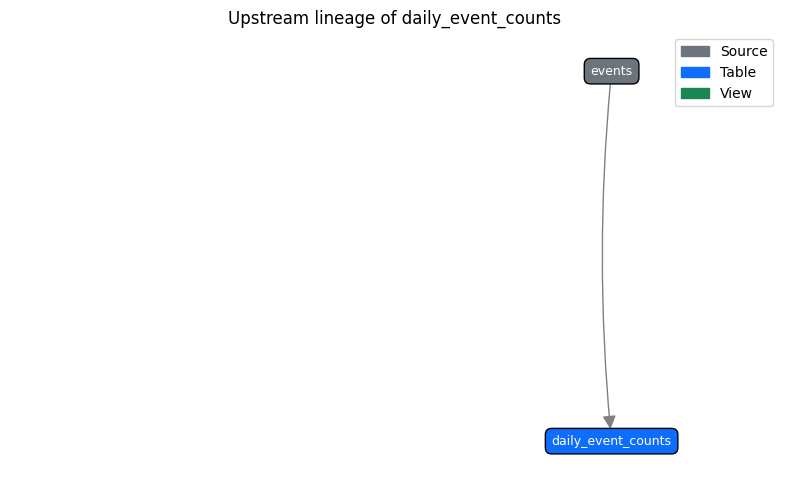

In [5]:
target = "demo.analytics.daily_event_counts"
ancestors = nx.ancestors(dag, target)
subgraph = dag.subgraph(ancestors | {target})

print(f"Upstream of {target}:")
print(f"  {subgraph.number_of_nodes()} nodes, {subgraph.number_of_edges()} edges")

pos_sub = dag_layout(subgraph)

fig, ax = plt.subplots(figsize=(8, 5))

nx.draw_networkx_edges(
    subgraph, pos_sub, ax=ax, arrows=True, arrowsize=20,
    edge_color="gray", connectionstyle="arc3,rad=0.05",
)

for node, (x, y) in pos_sub.items():
    label = node.split(".")[-1]
    color = color_map[dag.get_trouve(node).type.value]
    ax.text(
        x, y, label,
        ha="center", va="center",
        fontsize=9, color="white",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor=color,
            edgecolor="black",
            linewidth=1,
        ),
        zorder=3,
    )

legend_handles = [
    mpatches.Patch(color=c, label=t.capitalize()) for t, c in color_map.items()
]
ax.legend(handles=legend_handles, loc="upper right")
ax.set_title(f"Upstream lineage of {target.split('.')[-1]}")
ax.axis("off")
plt.tight_layout()
plt.show()
